In [26]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 


In [27]:
train = pd.read_csv("train.csv")

In [28]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
train.shape

(42000, 785)

In [30]:
train.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [31]:
X = train.drop("label",axis=1)
Y = train["label"]


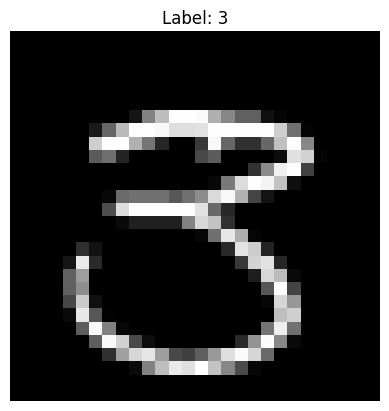

In [32]:
image = X.iloc[7].values.reshape(28,28)
plt.imshow(image, cmap="gray")
plt.title(f"Label: {Y.iloc[7]}")
plt.axis("off")
plt.show()

In [33]:
X = X.to_numpy()
Y =Y.to_numpy()

In [34]:
#Normalizing the Pixel values
X = X/255


In [35]:
print(X.min())
print(X.max())

0.0
1.0


In [36]:
print(X.shape)
Y = Y.reshape(-1,1)
Y = Y.T
print(Y.shape)

(42000, 784)
(1, 42000)


In [37]:
X = X.T
print(X.shape)

(784, 42000)


In [38]:
def initialize_parameters(layer_dims):
    np.random.seed(42)
    parameters = {}
    L = len(layer_dims)
    for l in range(1,L):
        parameters["W" + str(l)] = np.random.randn(layer_dims[l],layer_dims[l-1])*0.01
        parameters["b" + str(l)] = np.zeros((layer_dims[l],1))
    return parameters

In [39]:
def RELU(Z):
    A = np.maximum(0,Z)
    cache = Z
    return A,cache

In [40]:
def softmax(Z):
    Z_shift = Z - np.max(Z, axis=0, keepdims=True)
    exp_Z = np.exp(Z_shift)
    A = exp_Z / np.sum(exp_Z, axis=0, keepdims=True)
    cache = Z
    return A, cache

In [41]:
def linear_forward(A_prev,W,b):
    Z = np.dot(W,A_prev)+b
    cache = (A_prev,W,b)
    return Z,cache

In [42]:
def linear_activation_forward(A_prev,W,b,activation):
    Z,linear_cache = linear_forward(A_prev,W,b)
    if activation == "relu":
        A,activation_cache = RELU(Z)
    elif activation == "softmax":
        A,activation_cache = softmax(Z)
    cache = (linear_cache,activation_cache)
    return  A,cache

In [43]:
def model_forward(X,parameters):
    L = len(parameters)//2
    A = X
    caches = []
    for l in range(1,L):
        A,cache = linear_activation_forward(A,parameters["W" + str(l)],parameters["b" + str(l)],activation = "relu")
        caches.append(cache)
    AL,cache = linear_activation_forward(A,parameters["W" + str(L)], parameters["b" + str(L)],activation = "softmax")
    caches.append(cache)
    return AL,caches

In [44]:
layer_dims = [784,128,64,10]
parameters = initialize_parameters(layer_dims)
AL, caches = model_forward(X, parameters)

print(AL.shape)
print(len(caches))

(10, 42000)
3


In [45]:
def one_hot_encode(Y, num_classes=10):
    m = Y.shape[1]
    Y_one_hot = np.zeros((num_classes, m))
    for i in range(m):
        label = int(Y[0, i])
        Y_one_hot[label, i] = 1

    return Y_one_hot

In [46]:
Y = one_hot_encode(Y,)
Y.shape

(10, 42000)

In [47]:
def compute_cost(AL,Y):
    m = Y.shape[1]
    epsilon = 1e-8
    cost = -np.sum(Y * np.log(AL + epsilon))/m
    return cost

In [48]:
cost = compute_cost(AL,Y)
print(cost)

2.3026085797821962


In [52]:
def relu_backward(dA,activation_cache):
    Z = activation_cache
    dZ = np.array(dA,copy=True)
    dZ[Z<=0] = 0
    return dZ

In [53]:
def softmax_backward(AL,Y):
    dZ = AL - Y
    return dZ

In [54]:
def linear_backward(dZ,linear_cache):
    A_prev,W,b = linear_cache
    m = A_prev.shape[1]
    dW = (1/m)*np.dot(dZ,A_prev.T)
    db = (1/m) * np.sum(dZ,axis=1,keepdims=True)
    dA_prev = np.dot(W.T,dZ)
    
    return dA_prev,dW,db

In [55]:
def linear_activation_backward(dA,caches, activation):
    linear_cache,activation_cache = caches
    if activation == "relu":
        dZ = relu_backward(dA,activation_cache)
        dA_prev,dW,db = linear_backward(dZ,linear_cache)
    return dA_prev,dW,db

In [56]:
def backward_propagation(Al,Y,caches):
    grads = {}
    L = len(parameters)//2
    dZL = softmax_backward(AL,Y)
    dA_prev,dW,db = linear_backward(dZL,caches[L-1][0])
    grads["dW" + str(L)] = dW
    grads["db" + str(L)] = db
    
    for l in reversed(range(1,L)):
        dA_prev,dW,db = linear_activation_backward(dA_prev,caches[l-1],activation="relu")
        grads["dW" + str(l)] = dW
        grads["db" + str(l)] = db
    return grads

In [58]:
def update_params(parameters,grads,learning_rate):
    L = len(parameters)//2
    for l in range(1,L+1):
        parameters["W" + str(l)] -= learning_rate*grads["dW"+str(l)]
        parameters["b" + str(l)] -= learning_rate*grads["db"+str(l)]

In [62]:
grads = backward_propagation(AL,Y,caches)
print(grads["dW1"].shape)
print(grads["db1"].shape)
print(grads["dW2"].shape)
print(grads["db2"].shape)
print(grads["dW3"].shape)
print(grads["db3"].shape)

(128, 784)
(128, 1)
(64, 128)
(64, 1)
(10, 64)
(10, 1)


In [64]:
def model(X,Y,layer_dims,learning_rate= 0.01,epochs= 1000,print_cost = True):
    parameters = initialize_parameters(layer_dims)
    costs = []
    for i in range(epochs):
        AL, caches = model_forward(X,parameters)
        cost = compute_cost(AL,Y)
        grads = backward_propagation(AL,Y,caches)
        parameters = update_params(parameters,grads,learning_rate)
        
        if i%100 == 0:
            costs.append(cost)
            if print_cost:
                print(f"Iteration {i+1} : Cost {cost:.6f}")
                
    plt.plot(costs)
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title("Cost Curve")
    plt.show()
    
    return parameters